## Modelo T sem data augmentation

Conjunto de validação: train4

Conjunto de treino: train1, train2, train3 e train5

No código abaixo, nós definimos as variáveis train_dir, validation_dir e test_dir para guardar os caminhos das pastas que contêm os conjuntos das imagens de treino, validação e teste, respetivamente.

Definimos também que o tamanho da imagem iria ser 150x150, já que o VGG16 não suporta muito bem imagens com um tamanho demasiado baixo (32x32) e, com imagens com um tamanho superior, o modelo consegue extrair mais informação detalhada das imagens, o que é útil, pois assim consegues distinguir as diferentes classes mais facilmente.

Utilizamos a função image_data_set_from_directory, que le as imagens de cada pasta, com o intuito de as redimensionar para o tamanho acima definido e para as agrupar em batchs de 32 de tamanho.

In [2]:
from keras.utils import image_dataset_from_directory

train_dir = './train'
validation_dir = './validation'
test_dir = './test'

IMG_SIZE = 150

train_dataset = image_dataset_from_directory(train_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

validation_dataset = image_dataset_from_directory(validation_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

test_dataset = image_dataset_from_directory(test_dir,image_size=(IMG_SIZE, IMG_SIZE),batch_size=32)

Found 40000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.
Found 10000 files belonging to 10 classes.


Aqui nós importamos a rede VGG16 onde declaramos: 

weights='imagenet': isto indica que vamos utilizar os pesos pré-treinados no ImageNet.

incluede_top=False: isto indica que não vamos incluir a parte densa da rede no topo da rede.

input_shape=(150,150,3): isto indica que o tamanho da imagem que vamos utilizar é 150x150X3, onde o 3 indica que é uma imagem que tem 3 canais (RGB), ou seja, imagens com cor.

O conv_base.summary() mostra-nos a arquitetura da rede VGG16:
    
    - A primeira camada é uma camada de input com o tamanho da imagem que definimos anteriormente.

    - As duas camadas seguintes são camadas convolucionais, onde cada camada tem 64 filtros.

    - A proxima camada é uma camada de pooling, estas camadas são utilizadas para reduzir o tamanho da imagem para metade, neste caso reduz para 75x75, isto ajuda a reduzir o número de parâmetros.

    - As duas camadas seguintes são camadas convolucionais, onde cada camada tem 128 filtros.

    - A proxima camada é uma camada de pooling, reduz o tamanho da imagem para metade, neste caso reduz para 37x37.

    - As três camadas seguintes são camadas convolucionais, onde cada camada tem 256 filtros.

    - A última camada é uma camada de pooling, reduz o tamanho da imagem para metade, neste caso reduz para 18x18.

In [3]:
from tensorflow.keras.applications.vgg16 import VGG16

conv_base = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
conv_base.summary()

Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 150, 150, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 150, 150, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 150, 150, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 75, 75, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 75, 75, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 75, 75, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 37, 37, 128)       0     

Este código é apenas para verificar se os dados estão a ser processados corretamente, ou seja, se as imagens estão a ser redimensionadas para 150x150 e se estão a ser agrupadas em batchs de 32.

In [4]:
for data_batch, labels_batch in train_dataset:
  print('data batch shape:', data_batch.shape)
  print('labels batch shape:', labels_batch.shape)
  break

data batch shape: (32, 150, 150, 3)
labels batch shape: (32,)


Este código é apenas para exibir as 5 primeiras imagens de um batch de imagens, isto foi feito apenas para verificar se as imagens estão a ser carregadas corretamente.

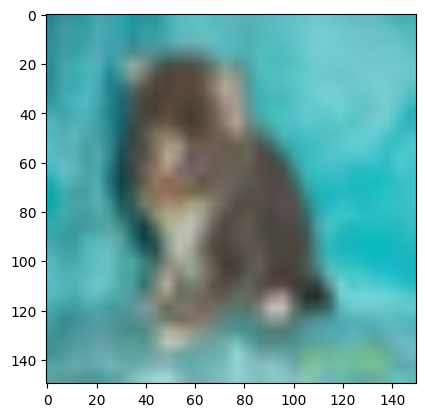

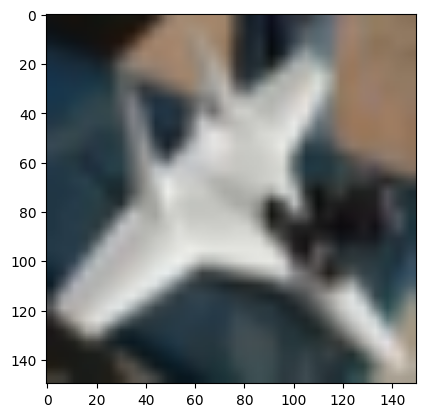

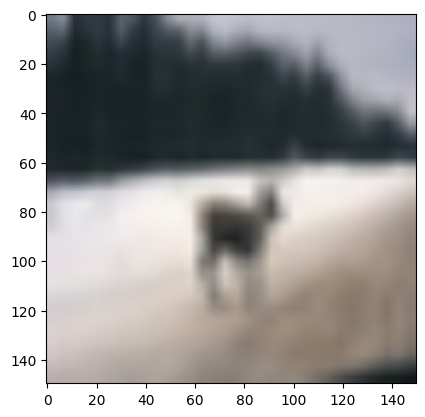

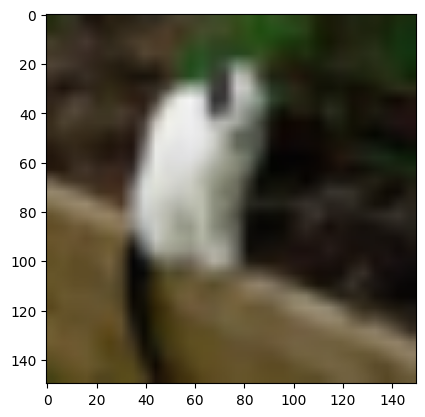

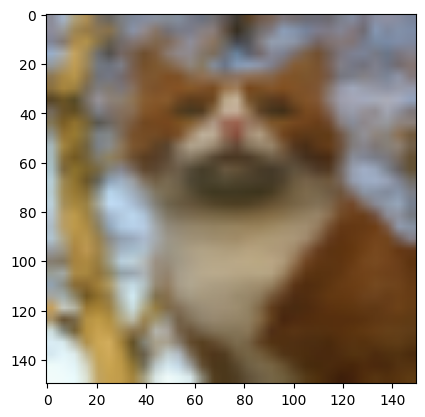

In [5]:
import matplotlib.pyplot as plt
for data_batch, _ in train_dataset.take(1):
  for i in range(5):
      plt.imshow(data_batch[i].numpy().astype("uint8"))
      plt.show()

Esta função é usada para obter as features e as labels para cada conjunto de imagens, neste caso, para o conjunto de treino, validação e teste.

In [6]:
from tensorflow import keras
import numpy as np
def get_features_and_labels(dataset):
    all_features = []
    all_labels = []
    for images, labels in dataset:
        preprocessed_images = keras.applications.vgg16.preprocess_input(images)
        features = conv_base.predict(preprocessed_images)
        all_features.append(features)
        all_labels.append(labels)
    return np.concatenate(all_features), np.concatenate(all_labels)

In [8]:
train_features, train_labels = get_features_and_labels(train_dataset)
val_features, val_labels = get_features_and_labels(validation_dataset)
test_features, test_labels = get_features_and_labels(test_dataset)

1/1 [==============================] - 0s 34ms/step


In [9]:
np.save('train_features.npy', train_features)
np.save('val_features.npy', val_features)
np.save('test_features.npy', test_features)
np.save('train_labels.npy', train_labels)
np.save('val_labels.npy', val_labels)
np.save('test_labels.npy', test_labels)

In [7]:
from numpy import load

train_features = load('train_features.npy')
val_features = load('val_features.npy')
test_features = load('test_features.npy')
train_labels = load('train_labels.npy')
val_labels = load('val_labels.npy')
test_labels = load('test_labels.npy')

Aqui nós construimos uma rede densa que desempenha o papel de classificação.

Esta rede é composta pelas seguintes camadas:
    
    - Flatten: esta camada é utilizada para converter a matriz de features 3D num vetor 1D.
    
    - Dense: esta camada é uma camada densa conectada com 256 neurónios.
    
    - Dropout: esta camada é utilizada para regularizar a rede, neste caso, estamos a desativar 50% dos neurónios.
    
    - Dense: esta camada é uma camada densa com 10 neurónios e a função de ativação é a softmax, esta camada é utilizada para classificar as imagens em 10 classes.

In [8]:
from tensorflow import keras
from keras import layers

inputs = keras.Input(shape=(4, 4, 512))
x = layers.Flatten()(inputs)
x = layers.Dense(256)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 4, 4, 512)]       0         
                                                                 
 flatten (Flatten)           (None, 8192)              0         
                                                                 
 dense (Dense)               (None, 256)               2097408   
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 10)                2570      
                                                                 
Total params: 2099978 (8.01 MB)
Trainable params: 2099978 (8.01 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Aqui nós compilamos o modelo, onde definimos a função de loss (sparse_categorical_crossentropy), o otimizador (rmsprop) e a métrica (accuracy).

In [9]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

Fizemos o callback com early stopping para o modelo parar de treinar quando o valor da loss do conjunto de validação não melhorar após 10 épocas (patience=10) e vai guardando o melhor modelo (save_best_only=True) no ficheiro modelo_T_without_data_augmentation.h5.

In [10]:
callbacks = [keras.callbacks.EarlyStopping(monitor="val_loss",patience=10), keras.callbacks.ModelCheckpoint(filepath='modelo_T_without_data_augmentation.h5', save_best_only=True, monitor='val_loss')]

Treinamos o modelo com 100 épocas com o conjunto de treino e validação e utilizamos o callback acima definido para parar o treino quando a loss do conjunto de validação não melhorar após 10 épocas.

In [15]:
history = model.fit(train_features, train_labels, epochs=100, validation_data=(val_features, val_labels), callbacks=callbacks) 

Epoch 1/100
1250/1250 [==============================] - 53s 42ms/step - loss: 10.8667 - accuracy: 0.7861 - val_loss: 4.9112 - val_accuracy: 0.8428
Epoch 2/100
   1/1250 [..............................] - ETA: 42s - loss: 8.5204 - accuracy: 0.7500

C:\Users\duart\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


1250/1250 [==============================] - 47s 38ms/step - loss: 4.0626 - accuracy: 0.8406 - val_loss: 3.2239 - val_accuracy: 0.8457
Epoch 3/100
1250/1250 [==============================] - 49s 39ms/step - loss: 2.8465 - accuracy: 0.8587 - val_loss: 3.5484 - val_accuracy: 0.8450
Epoch 4/100
1250/1250 [==============================] - 44s 35ms/step - loss: 2.6570 - accuracy: 0.8713 - val_loss: 3.9426 - val_accuracy: 0.8464
Epoch 5/100
1250/1250 [==============================] - 47s 37ms/step - loss: 2.5466 - accuracy: 0.8808 - val_loss: 4.1407 - val_accuracy: 0.8512
Epoch 6/100
1250/1250 [==============================] - 44s 35ms/step - loss: 2.5420 - accuracy: 0.8924 - val_loss: 4.8413 - val_accuracy: 0.8495
Epoch 7/100
1250/1250 [==============================] - 45s 36ms/step - loss: 2.5083 - accuracy: 0.8971 - val_loss: 4.8774 - val_accuracy: 0.8570
Epoch 8/100
1250/1250 [==============================] - 48s 38ms/step - loss: 2.4230 - accuracy: 0.9079 - val_loss: 5.3745 - val_

Depois de treinar o modelo, fizemos o gráfico da loss e da accuracy do conjunto de treino e validação.

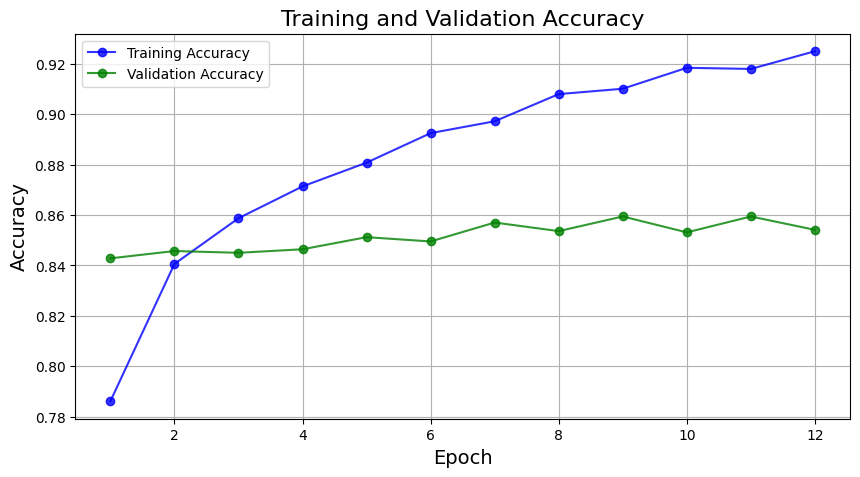

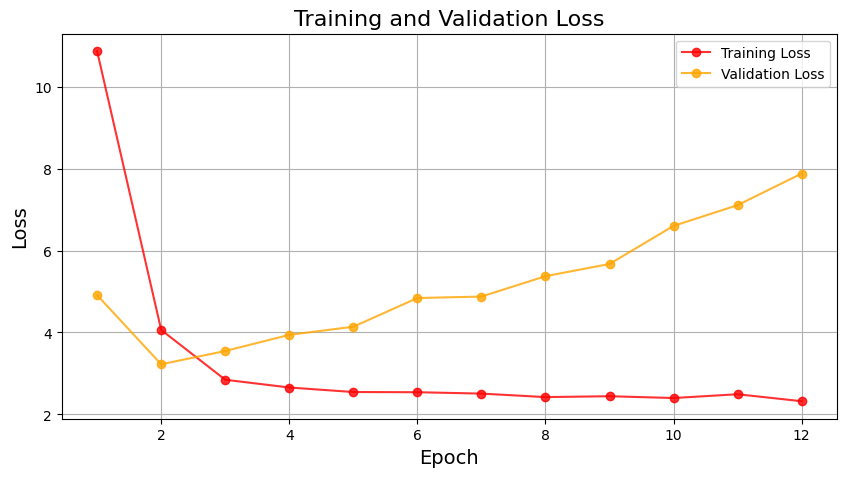

In [16]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, acc, 'o-', label='Training Accuracy', color='blue', alpha=0.8)
plt.plot(epochs, val_acc, 'o-', label='Validation Accuracy', color='green', alpha=0.8)
plt.title('Training and Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend()
plt.grid(True)

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss, 'o-', label='Training Loss', color='red', alpha=0.8)
plt.plot(epochs, val_loss, 'o-', label='Validation Loss', color='orange', alpha=0.8)
plt.title('Training and Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend()
plt.grid(True)

plt.show()

Pela observação dos gráficos podemos ver que o modelo está a fazer overfitting, ou seja, a accuracy do conjunto de treino está a aumentar, mas a accuracy do conjunto de validação está a diminuir e a loss do conjunto de treino está a diminuir, mas a loss do conjunto de validação está a aumentar.

A accuracy do conjunto de treino começa com um valor mais baixo que o conjunto de validação, mas a partir da época 3, a accuracy do conjunto de treino ultrapassa a accuracy do conjunto de validação. A accuracy do conjunto de treino está progessivamente ao aumentar chegando a um valor máximo 0.9249 na época 12, enquanto a accuracy do conjunto de validação fica estagnado mais ou menos num valor de 0.84 a 0.85. 

A loss do conjunto de treino começa com um valor mais alto que o conjunto de validação, a partir da época 3, a loss do conjunto de validação ultrapassa a loss do conjunto de treino. A loss no conjunto de treino começa com um valor muito alto, 10.87, mas vai diminuindo até à época 12, onde atinge o valor de 2.3222, enquanto a loss do conjunto de validação começa num valor mais baixo, 4.9, mas vai aumentando até à época 12, onde atinge o valor de 7.88.

Aqui neste código, nós juntamos o modelo de extração de features, o VGG16, com a rede densa que classifica as imagens que foi definida e treinada por nós.

In [17]:
from keras import models
inputs = keras.Input(shape=(150, 150, 3))
x = keras.applications.vgg16.preprocess_input(inputs)
x = conv_base(x)
outputs = model(x)
full_model = keras.Model(inputs, outputs)

In [18]:
full_model.compile(loss="sparse_categorical_crossentropy", optimizer="rmsprop", metrics=["accuracy"])

Depois de compilarmos o modelo, nós fizemos o evaluate do modelo com o conjunto de teste, para verificarmos a accuracy do modelo com um conjunto de imagens que ele nunca viu.
O valor obtido da accuracy foi de 0.86, ou seja, acerta em 86% das imagens. Apesar de ter um valor de accuracy que pode ser considerado bom, o valor de loss é alto (7.47) e o modelo está a fazer overfitting, como foi observado nos gráficos acima.

**Para minimizar este overfitting, aplicamos o mesmo modelo, mas com data augmentation, para ver se conseguimos melhorar o modelo. (Isto foi feito no ficheiro modelo_T_with_data_augmentation)**

In [19]:
test_loss, test_acc = full_model.evaluate(test_dataset)
print('test_acc:', test_acc)
print('test_loss:', test_loss)

313/313 [==============================] - 827s 3s/step - loss: 7.4742 - accuracy: 0.8595
test_acc: 0.859499990940094
test_loss: 7.474189281463623


Aqui nós fizemos a matriz de confusão para verificarmos a quantidade de imagens que o modelo classificou corretamente e incorretamente para cada classe.

1/1 [==============================] - 2s 2s/step


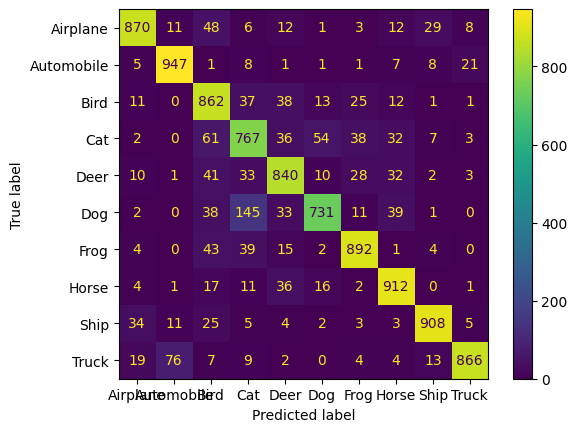

In [25]:
from sklearn import metrics


y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = full_model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

conf_mat = metrics.confusion_matrix(y_true, y_pred)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix=conf_mat, display_labels=["Airplane", "Automobile", "Bird", "Cat", "Deer", "Dog", "Frog", "Horse", "Ship", "Truck"])
cm_display.plot()
plt.show()

Por análise da matriz de confusão, entende-se que o modelo apresenta resultados maioritariamente satisfatórios, com exceção de algumas classes que apresentam uma taxa de acerto menor. A destacar são as classes 'dog' e 'cat', que são aquelas em que o modelo apresenta maior dificuldade em classificar corretamente, tendo em 1000 imagens acertado em 731 e 767, respetivamente. Outro ponto a destacar é que a classe 'dog' é algumas vezes confundida (145 vezes) com a classe 'cat'. As classes com maior taxa de acerto são 'automobile' e 'horse', com 947 e 912 imagens corretamente classificadas, respetivamente.

Neste código, nós apenas fizemos o predict de uma imagem para ver se ele consegue prever a classe correta da imagem.

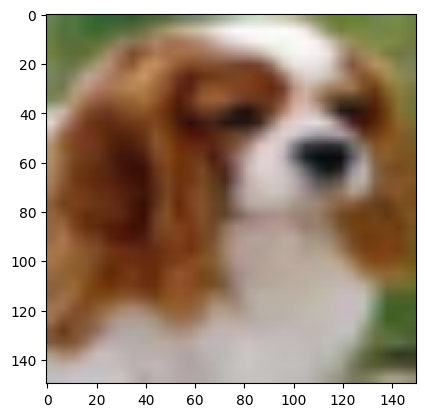

(1, 150, 150, 3)
1/1 [==============================] - 0s 439ms/step
Result:  dog
Result:  [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]]


In [21]:
from keras.preprocessing import image
import numpy as np
import tensorflow as tf

img = tf.keras.preprocessing.image.load_img('./test/005_dog/blenheim_spaniel_s_000123.png', target_size=(150, 150), interpolation='bilinear')
plt.imshow(img)
plt.show()
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
print(img_array.shape)
result = full_model.predict(img_array)
whatIsIt = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

predicted_classes = result.round()
predicted_indices = np.where(predicted_classes == 1)[1]

for index in predicted_indices:
    print("Result: ", whatIsIt[index])
print("Result: ", result.round())

Pelo o output obtido, podemos ver que o modelo consegue prever a classe correta da imagem.

In [23]:
full_model.save('modelo_T_without_data_augmentation.h5')